In [ ]:
# To config Google Colab

# Install MedMNIST and privacy tools
# !pip install medmnist fire
# !pip install opacus==1.4.0

# Check
# import torch
# print(f"PyTorch version: {torch.__version__}")
# print(f"CUDA available: {torch.cuda.is_available()}")
# print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'Not available'}")

In [10]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim # (SGD), Adam, RMSprop, optimizer.step() 
import torch.utils.data as data 

import torchvision.transforms as transforms # suite of tools for image preprocessing and data augmentation, commonly used in computer vision tasks.
# transforms.Compose to build complex preprocessing pipelines 
# Supports both PIL images and PyTorch tensors.
import glob
import medmnist
from medmnist import INFO, Evaluator
import pandas as pd
import os
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
import time 

In [11]:
from utility import get_datasets, get_dataloaders, get_data_info, scores
from model import get_model, get_optimizer, get_loss_function 

In [12]:
data_flag = 'bloodmnist'
info = get_data_info(data_flag)

In [13]:
info

{'python_class': 'BloodMNIST',
 'description': 'The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/bloodmnist.npz?download=1',
 'MD5': '7053d0359d879ad8a5505303e11de1dc',
 'url_64': 'https://zenodo.org/records/10519652/files/bloodmnist_64.npz?download=1',
 'MD5_64': '2b94928a2ae4916078ca51e05b6b800b',
 'url_128': 'https://zenodo.org/records/10519652/files/bloodmnist_128.npz?download=1',
 'MD5_128': 'adace1e0ed228fccda1f39692059dd4c',
 'url_224': 'https://zenodo.org/records/10519652/files/bloodmnist

## Main Training Parameters

In [14]:
NUM_EPOCHS = 100
BATCH_SIZE = 128 
LR = 0.001 
n_channels = info['n_channels']
n_classes = len(info['label'])

## Preprocess and data loading

In [15]:
train_dataset, val_dataset, test_dataset = get_datasets(data_flag)
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
val_loader_at_eval = data.DataLoader(dataset=val_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz
Using downloaded and verified file: /Users/anastasiia_popova/.medmnist/bloodmnist.npz


In [16]:
#train_dataset.montage(length=7, save_folder="plots")

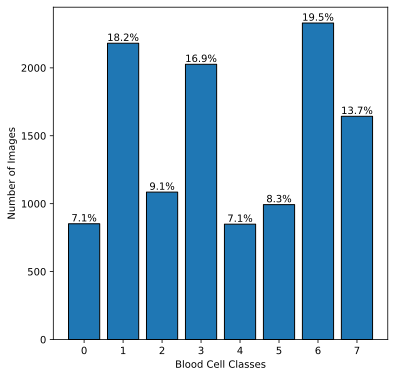

In [17]:
def plot_dataset_distribution(train_dataset, info):
    """
    Plot the distribution of classes in the dataset
    with additional statistics
    """

    all_labels = []
    for _, label in train_dataset:
        all_labels.append(label.item())
    
    all_labels = np.array(all_labels)
    classes = np.unique(all_labels)

            
    class_counts = {c: np.sum(all_labels == c) for c in classes}

    plt.figure(figsize=(6, 6))
    bars = plt.bar(range(len(classes)), 
                  [class_counts[c] for c in classes], 
                  edgecolor='black')
    
    # Add percentage labels
    for bar, count in zip(bars, [class_counts[c] for c in classes]):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{100 * count / len(all_labels):.1f}%', 
                ha='center', va='bottom')
    
    plt.xticks(range(len(classes)), [i for i in classes])
    plt.xlabel('Blood Cell Classes')
    plt.ylabel('Number of Images')
    #plt.title('Distribution of classes in the training dataset')
    plt.savefig("plots/Distribution of classes in the training dataset.png",dpi=330)


plot_dataset_distribution(train_dataset, info)

## Baseline Classifier

In [31]:
class_counts = torch.zeros(n_classes, dtype=torch.int64)
total_count = 0

# to count each class in the train dataset
for _, labels in train_loader:
    for i in range(n_classes):
        class_counts[i] += (labels == i).sum()
    total_count += len(labels)

# calculate class probabilities
class_probs = class_counts.float() / total_count

def get_baseline_probabilities(num_samples, probabilities):
    """
    Generates a (num_samples, n_classes) probability matrix for the baseline model.
    Each row is a copy of the training set's class distribution.
    """
    return np.tile(probabilities.numpy(), (num_samples, 1))

# Get baseline probability predictions 
baseline_probabilities = get_baseline_probabilities(len(test_dataset), class_probs)

evaluator = Evaluator(data_flag, 'test')
metrics = evaluator.evaluate(baseline_probabilities)

print("--------------------------------------------------")
print(f"ACC (test): {metrics.ACC:.4f}") 
print(f"AUC (test): {metrics.AUC:.4f}") 


--------------------------------------------------
ACC (test): 0.1947
AUC (test): 0.5000


## Model

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(n_channels, n_classes)

optimizer = get_optimizer(model)
criterion = get_loss_function(info['task'])


Using device: cpu


In [15]:
# Only trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

# Count only top-level child modules (not counting submodules within containers like nn.Sequential)
num_layers = sum(1 for _ in model.children())
print(f"Number of top-level layers: {num_layers}")

# Count all modules (including nested)
num_all_layers = sum(1 for _ in model.modules())
print(f"Total number of modules (including nested): {num_all_layers}")

Trainable parameters: 235096
Number of top-level layers: 6
Total number of modules (including nested): 29


In [16]:
# Define the path to save the models
MODEL_SAVE_PATH = 'weights/non_private_models'

## Training 

In [18]:
loss_curve_train = []
loss_curve_val = []

auc_curve_train = []
auc_curve_val = []

# only for 1 initit of weights
acc_curve_train = []
acc_curve_val = []

# K is the number of attempts to average the final accuracy and time for training 

# Lists to track metrics
best_models = []  # To store file paths of best models
early_stop_epochs = []  # To track when each run stopped
early_stop_times = []  # To track training time until early stopping
av_epoch_time = []

# Early stopping parameters
patience = 10  # number of epochs we wait for improvement
min_delta = 0.01  # minimum improvement

for K in range(3):

    # need to init model weights 
    model = get_model(n_channels, n_classes)
    optimizer = get_optimizer(model, lr = LR)
    criterion = get_loss_function(info['task'])

    # Early stopping variables
    best_val_metric = 0  # For ACC (higher is better)
    best_epoch = 0
    no_improve_count = 0
    best_model_path = None

    # Time tracking
    total_time = 0
    epoch_times = []
    
    # For tracking metrics
    loss_curve_train = []
    loss_curve_val = []
    

    for epoch in range(NUM_EPOCHS):
        train_loss = 0.0
        train_batches = 0
    
        # Training phase
        start_epoch_time = time.perf_counter() 

        model.train()        
        for inputs, targets in tqdm(train_loader):

            inputs = inputs.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)

            # can be used for other 2D datasets 
            if info['task'] == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                loss = criterion(outputs, targets)
            else:
                targets = targets.squeeze().long()
                loss = criterion(outputs, targets)
            
            loss.backward()
            optimizer.step()
    
            train_loss += loss.item()
            train_batches += 1
    
        avg_train_loss = train_loss / train_batches if train_batches > 0 else 0
        loss_curve_train.append(avg_train_loss)
  
        # Validation 
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            
            for val_inputs, val_targets in val_loader:
                val_inputs = val_inputs.to(device)
                val_targets = val_targets.to(device)
                
                val_outputs = model(val_inputs)
                if info['task'] == 'multi-label, binary-class':
                    val_targets = val_targets.to(torch.float32)
                    v_loss = criterion(val_outputs, val_targets)
                else:
                    val_targets = val_targets.squeeze().long()
                    v_loss = criterion(val_outputs, val_targets)
                    
                val_loss += v_loss.item()
                val_batches += 1
                
        avg_val_loss = val_loss / val_batches if val_batches > 0 else 0
        loss_curve_val.append(avg_val_loss)

        # ---- Calculate validation ACC for early stopping ----
        metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
                
        current_metric = metric_val.ACC 
        
        end_epoch_time = time.perf_counter()
        epoch_time = end_epoch_time - start_epoch_time
        epoch_times.append(epoch_time)
        total_time += epoch_time
        av_epoch_time.append(epoch_time)
        
        # we save acc and auc curves only for 1 inititalization as they don't significantly differ + evaluation takes time
        if K == 0: 
            metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

            auc_curve_train.append(metric_train.AUC)
            acc_curve_train.append(metric_train.ACC)
            
            metric_val = scores('val', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
            auc_curve_val.append(metric_val.AUC)
            acc_curve_val.append(metric_val.ACC)
                
        print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}, val loss: {avg_val_loss:.4f}")
        print(f"Epoch {epoch+1} training time: {epoch_time:.2f} seconds")
        
        # Early stopping check
        if epoch > 40 and current_metric > best_val_metric + min_delta:
            print(f"Validation metric improved from {best_val_metric:.4f} to {current_metric:.4f}")
            best_val_metric = current_metric
            best_epoch = epoch
            no_improve_count = 0
            
            # Save best model
            model_filename = f'model_init_{K}_best_epoch_{epoch}_auc_{metric_val.AUC:.4f}_acc_{metric_val.ACC:.4f}.pth'
            model_path = os.path.join(MODEL_SAVE_PATH, model_filename)
            torch.save(model.state_dict(), model_path)
            best_model_path = model_path
            print(f"Saved best model to {model_path}")
        else:
            if epoch > 40:
                no_improve_count += 1
                print(f"No improvement for {no_improve_count} epochs")
            
        # Check if we should stop
        if epoch > 40 and no_improve_count >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Training phase finishes here
    early_stop_epochs.append(best_epoch + 1)  # +1 for 1-based indexing
    early_stop_times.append(total_time)
    best_models.append(best_model_path)

    
    print("--------------------------------")
    print(f"Instance {K}")
    print(f"Best epoch: {best_epoch + 1}")
    print(f"Best validation ACC: {best_val_metric:.4f}")
    print(f"Training time until best model: {sum(epoch_times[:best_epoch+1]):.2f} seconds")
    print(f"Total training time: {total_time:.2f} seconds")



100%|███████████████| 94/94 [00:07<00:00, 12.20it/s]


Epoch 1 train loss: 0.8521, val loss: 0.5122
Epoch 1 training time: 8.94 seconds


100%|███████████████| 94/94 [00:07<00:00, 13.34it/s]


Epoch 2 train loss: 0.4356, val loss: 0.4477
Epoch 2 training time: 8.04 seconds


100%|███████████████| 94/94 [00:07<00:00, 13.32it/s]


...

Epoch 50 train loss: 0.0000, val loss: 0.2507
Epoch 50 training time: 9.07 seconds
No improvement for 8 epochs


100%|███████████████| 94/94 [00:07<00:00, 11.98it/s]


Epoch 51 train loss: 0.0000, val loss: 0.2531
Epoch 51 training time: 8.86 seconds
No improvement for 9 epochs


100%|███████████████| 94/94 [00:08<00:00, 11.70it/s]


Epoch 52 train loss: 0.0000, val loss: 0.2553
Epoch 52 training time: 9.05 seconds
No improvement for 10 epochs
Early stopping at epoch 52
--------------------------------
Instance 2
Best epoch: 42
Best validation ACC: 0.9562
Training time until best model: 387.96 seconds
Total training time: 482.31 seconds


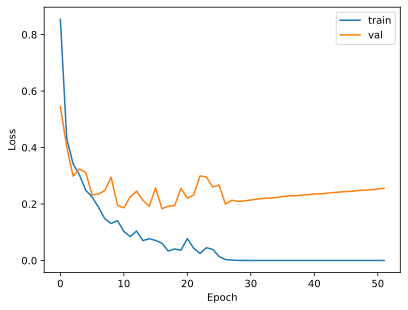

In [19]:
# the first trained model is shown 
plt.plot(loss_curve_train, label='train')
plt.plot(loss_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

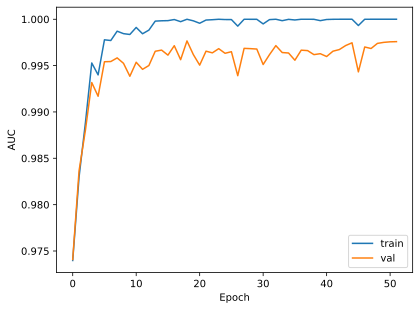

In [20]:
# the first trained model is shown 
plt.plot(auc_curve_train, label='train')
plt.plot(auc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

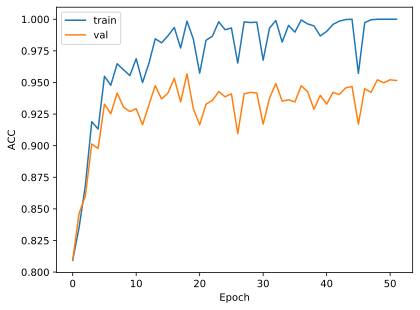

In [21]:
plt.plot(acc_curve_train, label='train')
plt.plot(acc_curve_val, label='val')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.legend()

## Evaluation

In [22]:
print('==> Evaluating ...')
final_auc_train = []
final_acc_train = []

final_auc_test = []
final_acc_test = []

for i, model_path in enumerate(best_models):
    model = get_model(n_channels, n_classes)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    metric_train = scores('train', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)
                
    final_auc_train.append(metric_train.AUC)
    final_acc_train.append(metric_train.ACC)
    
    metric_test = scores('test', model, info, data_flag, train_loader_at_eval, val_loader_at_eval, test_loader)

    final_auc_test.append(metric_test.AUC)
    final_acc_test.append(metric_test.ACC)
    
print("--------------------------------------------------")    
print(f"Average stopping epoch: {np.mean(early_stop_epochs):.1f} ± {np.std(early_stop_epochs):.1f}")
print(f"Average training time: {np.mean(early_stop_times):.2f} ± {np.std(early_stop_times):.2f} seconds")
print(f"Average epoch time: {np.mean(av_epoch_time):.2f} ± {np.std(av_epoch_time):.2f} seconds")

print("--------------------------------------------------")
print(f"ACC (train): {np.mean(final_acc_train):.4f}  ± {np.std(final_acc_train):.4f}") 
print(f"AUC (train): {np.mean(final_auc_train):.4f} ± {np.std(final_auc_train):.4f}") 
print("--------------------------------------------------")
print(f"ACC (test): {np.mean(final_acc_test):.4f} ± {np.std(final_acc_test):.4f}") 
print(f"AUC (test): {np.mean(final_auc_test):.4f} ± {np.std(final_auc_test):.4f}") 



==> Evaluating ...
--------------------------------------------------
Average stopping epoch: 42.0 ± 0.0
Average training time: 467.13 ± 11.88 seconds
Average epoch time: 8.98 ± 0.84 seconds
--------------------------------------------------
ACC (train): 0.9986  ± 0.0019
AUC (train): 1.0000 ± 0.0000
--------------------------------------------------
ACC (test): 0.9411 ± 0.0053
AUC (test): 0.9963 ± 0.0004
